# Practical Exercise: Perceptron and Linear Support Vector Machine (SVM)

In this notebook, we trace the ideas from **linear classification** to **maximum-margin classifiers**.

## Learning Objectives
1. Understand what a hyperplane is and how it defines a binary classifier.
2. Compare loss functions: 0-1, Perceptron, Logistic, and Hinge loss.
3. Implement the Perceptron update rule from scratch.
4. Understand *why* margin matters and how to measure it.
5. Train a Hard-Margin Linear SVM and identify support vectors.
6. Observe the effect of parameter $C$ in Soft-Margin SVM.

---
## Theory Recap

| Concept | Formula |
|---|---|
| Hyperplane | $w^T x + b = 0$ |
| Prediction | $\hat{y} = \text{sign}(w^T x + b)$ |
| Signed distance | $\gamma_n = \dfrac{y_n(w^T x_n + b)}{\|w\|}$ |
| Perceptron update | $w \leftarrow w + y_n x_n$ (when $y_n(w^T x_n + b) \le 0$) |
| Margin | $\dfrac{2}{\|w\|}$ |
| Hard-SVM objective | $\min \dfrac{1}{2}\|w\|^2 \quad \text{s.t. } y_n(w^T x_n + b) \ge 1$ |
| Soft-SVM objective | $\min \dfrac{1}{2}\|w\|^2 + C\sum_n \xi_n \quad \text{s.t. } y_n(w^T x_n + b) \ge 1 - \xi_n$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

---
## Part 1: Hyperplanes and Binary Classification

A **hyperplane** in 2D is a line $w_1 x_1 + w_2 x_2 + b = 0$ that divides the space into two half-spaces.

Given a weight vector $w$ and bias $b$, the **prediction rule** is:
$$\hat{y} = \text{sign}(w^T x + b) = \begin{cases} +1 & \text{if } w^T x + b > 0 \\ -1 & \text{if } w^T x + b < 0 \end{cases}$$

Geometrically:
- $w$ is a vector **perpendicular** to the hyperplane.
- $b$ (bias) **shifts** the hyperplane away from the origin.
- Changing the direction of $w$ **rotates** the boundary; changing $b$ **translates** it.

---
**Requirement 1 — Predict class labels**

Complete the `predict` function that computes $\hat{y} = \text{sign}(w^T x + b)$ for each sample.

In [ ]:
def predict(X, w, b):
    """
    Return class predictions (+1 or -1) for each row of X.
    Input:
      X : (N, 2) array of data points
      w : (2,)   weight vector
      b : scalar bias
    Output:
      y_pred : (N,) array of +1 or -1
    """
    # --- WRITE YOUR CODE HERE ---
    pass


# ---- Helper: draw a decision boundary ----
def plot_boundary(X, y, w, b, title='Decision Boundary'):
    colors = ['tomato' if yi == 1 else 'steelblue' for yi in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', zorder=3)
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    if w[1] != 0:
        plt.plot(x1, -(w[0] * x1 + b) / w[1], 'k-', linewidth=2, label='Decision boundary')
    legend_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
               markersize=10, markeredgecolor='k', label='Class +1'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=10, markeredgecolor='k', label='Class -1'),
    ]
    plt.legend(handles=legend_handles)
    plt.title(title); plt.xlabel('$x_1$'); plt.ylabel('$x_2$')


# ---- Toy linearly separable dataset ----
X_toy, y_toy = make_blobs(n_samples=40, centers=[[-1.5, -1.5], [1.5, 1.5]],
                           cluster_std=0.6, random_state=0)
y_toy = np.where(y_toy == 0, -1, 1)

w_manual = np.array([1.0, 1.0])
b_manual = 0.0

y_pred = predict(X_toy, w_manual, b_manual)
accuracy = np.mean(y_pred == y_toy)

plot_boundary(X_toy, y_toy, w_manual, b_manual,
              title=f'Manual hyperplane  |  w={w_manual}, b={b_manual}  |  Accuracy: {accuracy:.0%}')
plt.show()
print(f"Accuracy: {accuracy:.0%}")
print("Try w=[2,1] or b=-1 and observe how the boundary rotates/shifts.")

---
## Part 2: Classification Loss Functions

Let $z = y \cdot (w^T x + b)$ be the **margin score** for a point:
- $z > 0$ → predicted correctly
- $z \le 0$ → predicted incorrectly

Four common loss functions express the **cost of a prediction** as a function of $z$:

| Loss | Formula | Key property |
|---|---|---|
| 0-1 loss | $\mathbf{1}[z \le 0]$ | Ideal but non-differentiable |
| Perceptron loss | $\max(0, -z)$ | Zero as soon as $z > 0$ |
| **Hinge loss** | $\max(0, 1 - z)$ | Zero only when $z \ge 1$ — rewards a **safety margin** |
| Logistic loss | $\log(1 + e^{-z})$ | Always positive; probabilistic interpretation |

The hinge loss is the foundation of SVM: it is zero only when the model is correct **and** confident by at least 1. This naturally drives SVM to maximize the margin.

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/lh/k6dt2yzs4vv8z5xzjdh7xctm0000gn/T/ipykernel_5808/915749080.py:15: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$z = y \cdot (w^T x + b)$'); plt.ylabel('Loss')


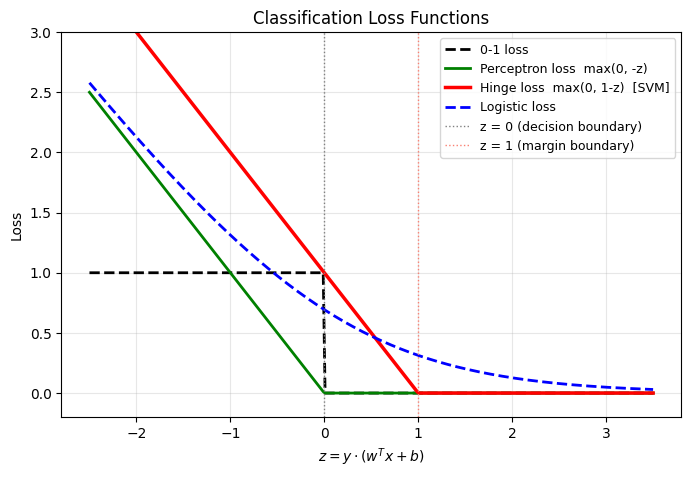

Key insight:
  Perceptron loss = 0 as soon as z > 0  → does not reward confidence.
  Hinge loss      = 0 only when z >= 1  → demands a safety margin of 1.
  This is why minimizing hinge loss is equivalent to maximizing the SVM margin.


In [3]:
z_vals = np.linspace(-2.5, 3.5, 300)

zero_one  = (z_vals <= 0).astype(float)
perceptron = np.maximum(0, -z_vals)
hinge      = np.maximum(0, 1 - z_vals)
logistic   = np.log(1 + np.exp(-z_vals))

plt.plot(z_vals, zero_one,   'k--', linewidth=2,   label='0-1 loss')
plt.plot(z_vals, perceptron, 'g-',  linewidth=2,   label='Perceptron loss  max(0, -z)')
plt.plot(z_vals, hinge,      'r-',  linewidth=2.5, label='Hinge loss  max(0, 1-z)  [SVM]')
plt.plot(z_vals, logistic,   'b--', linewidth=2,   label='Logistic loss')
plt.axvline(x=0, color='gray',   linestyle=':', linewidth=1, label='z = 0 (decision boundary)')
plt.axvline(x=1, color='salmon', linestyle=':', linewidth=1, label='z = 1 (margin boundary)')
plt.ylim(-0.2, 3); plt.grid(True, alpha=0.3)
plt.xlabel('$z = y \cdot (w^T x + b)$'); plt.ylabel('Loss')
plt.legend(fontsize=9); plt.title('Classification Loss Functions')
plt.show()

print("Key insight:")
print("  Perceptron loss = 0 as soon as z > 0  → does not reward confidence.")
print("  Hinge loss      = 0 only when z >= 1  → demands a safety margin of 1.")
print("  This is why minimizing hinge loss is equivalent to maximizing the SVM margin.")

---
## Part 3: Perceptron Algorithm from Scratch

The Perceptron is a simple linear classifier trained with a **mistake-driven** update rule:

$$\text{If } y_n(w^T x_n + b) \le 0 \text{ (misclassified):} \quad w \leftarrow w + y_n x_n, \quad b \leftarrow b + y_n$$

Intuition: if $x_n$ is misclassified, we push $w$ towards the correct side by adding $y_n x_n$.

**Convergence guarantee:** If the data is linearly separable, the Perceptron converges in a finite number of steps. However, the final boundary is **not guaranteed to have maximum margin** — it depends on the order of training samples.

---
**Requirement 2 — Implement the Perceptron update rule**

Complete the two lines inside the `if score <= 0` block.

In [ ]:
class Perceptron:
    def __init__(self, n_features):
        self.w = np.zeros(n_features)
        self.b = 0.0

    def fit(self, X, y, n_epochs=20):
        history = []   # list of (w copy, b, n_errors) per epoch
        for epoch in range(n_epochs):
            n_errors = 0
            for i in range(len(X)):
                x_i, y_i = X[i], y[i]
                score = y_i * (self.w @ x_i + self.b)
                if score <= 0:   # misclassified
                    # --- WRITE YOUR CODE HERE ---
                    pass
                    n_errors += 1
            history.append((self.w.copy(), self.b, n_errors))
            if n_errors == 0:
                break
        return history

    def predict(self, X):
        return np.sign(X @ self.w + self.b)


perc = Perceptron(n_features=2)
history = perc.fit(X_toy, y_toy, n_epochs=30)

# --- Plot mistakes per epoch ---
errors_per_epoch = [h[2] for h in history]
plt.bar(range(1, len(errors_per_epoch) + 1), errors_per_epoch, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Number of mistakes')
plt.title('Perceptron: mistakes per epoch')
plt.show()

print(f"Converged in {len(history)} epochs.")
print(f"Final w = {perc.w},  b = {perc.b:.2f}")

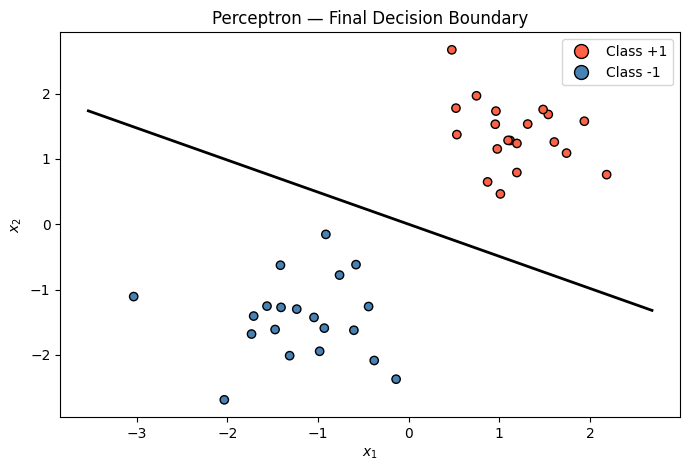

The boundary separates the data correctly — but is it in the BEST position?
The Perceptron gives no guarantee on how far the boundary is from either class.


In [5]:
plot_boundary(X_toy, y_toy, perc.w, perc.b,
              title='Perceptron — Final Decision Boundary')
plt.show()
print("The boundary separates the data correctly — but is it in the BEST position?")
print("The Perceptron gives no guarantee on how far the boundary is from either class.")

---
## Part 4: Why Margin Matters

Many hyperplanes can separate the data correctly. Which one should we pick?

The **geometric margin** of a single point $x_n$ to hyperplane $(w, b)$ is:
$$\gamma_n = \frac{y_n(w^T x_n + b)}{\|w\|}$$

The **margin of a classifier** is the minimum distance over all training points:
$$\gamma = \min_{n} \gamma_n$$

A larger $\gamma$ means the boundary is far from all points, which leads to **better generalization** on unseen data. This is the motivation for SVM: find the hyperplane with the **largest margin**.

---
**Requirement 3 — Compute the geometric margin**

Complete `compute_margin` using the formula above.

In [ ]:
def compute_margin(X, y, w, b):
    """
    Return the geometric margin of hyperplane (w, b) on dataset (X, y).
    That is: min over all n of  y_n * (w^T x_n + b) / ||w||
    """
    # --- WRITE YOUR CODE HERE ---
    pass


margin_perceptron = compute_margin(X_toy, y_toy, perc.w, perc.b)
print(f"Perceptron margin: {margin_perceptron:.4f}")

# Compare two boundaries side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_boundary_ax(ax, X, y, w, b, title):
    colors = ['tomato' if yi == 1 else 'steelblue' for yi in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', zorder=3)
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    if w[1] != 0:
        ax.plot(x1, -(w[0]*x1 + b)/w[1], 'k-', linewidth=2)
    m = compute_margin(X, y, w, b)
    ax.set_title(f'{title}\nMargin = {m:.4f}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plot_boundary_ax(axes[0], X_toy, y_toy, perc.w, perc.b, 'Perceptron boundary')
plot_boundary_ax(axes[1], X_toy, y_toy, np.array([1.0, 1.0]), -0.2,
                 'Another boundary (w=[1,1], b=-0.2)')
plt.tight_layout()
plt.show()
print("Which boundary would generalize better to unseen data?")

---
## Part 5: Hard-Margin Linear SVM

Instead of stopping at any separating hyperplane, SVM finds the one with **maximum margin**:
$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{subject to } y_n(w^T x_n + b) \ge 1 \quad \forall n$$

Minimizing $\|w\|^2$ is equivalent to maximizing $\dfrac{2}{\|w\|}$ (the margin width).

The constraint $y_n(w^T x_n + b) \ge 1$ defines two **margin hyperplanes**:
- $w^T x + b = +1$ (positive side)
- $w^T x + b = -1$ (negative side)

Points that lie exactly on these boundaries are called **support vectors** — they are the only training points that determine $w$ and $b$. All other points could be removed without changing the solution.

**Dual form:** Using Lagrange multipliers $\alpha_n \ge 0$, the solution satisfies:
$$w = \sum_{n} \alpha_n y_n x_n$$
Only support vectors have $\alpha_n \ne 0$.

In [7]:
# Large C approximates hard-margin (no violations allowed)
clf_hard = SVC(kernel='linear', C=1e6)
clf_hard.fit(X_toy, y_toy)

w_svm = clf_hard.coef_[0]
b_svm = clf_hard.intercept_[0]
sv    = clf_hard.support_vectors_

print(f"SVM   w = {w_svm}")
print(f"SVM   b = {b_svm:.4f}")
print(f"Number of support vectors : {len(sv)}")
print(f"SVM margin                : {2 / np.linalg.norm(w_svm):.4f}")
print(f"Perceptron margin         : {margin_perceptron:.4f}")

SVM   w = [0.84738155 0.60811096]
SVM   b = -0.1321
Number of support vectors : 3
SVM margin                : 1.9175
Perceptron margin         : 0.5422


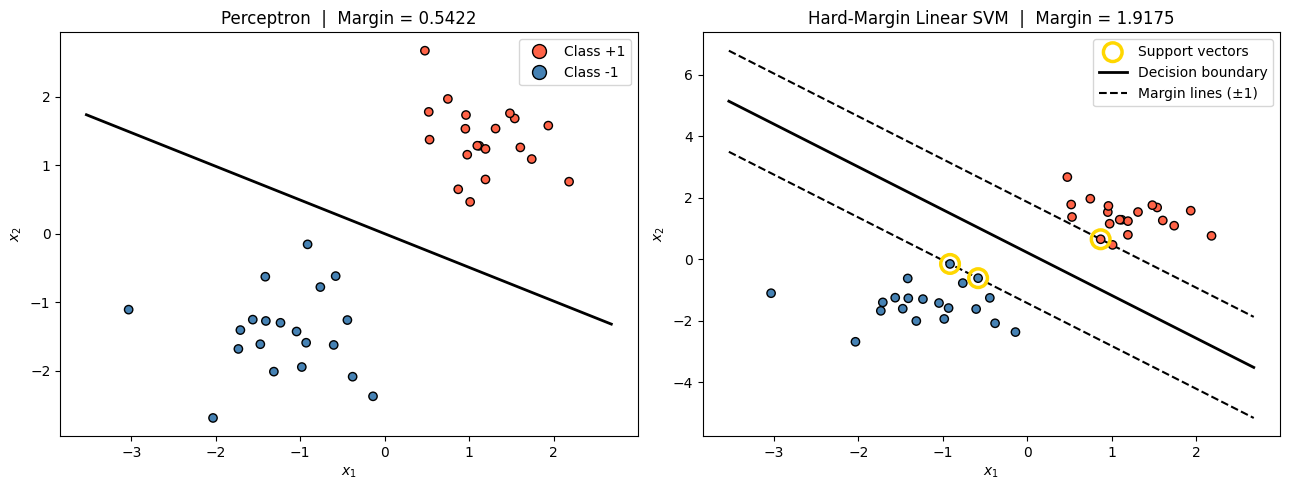

Gold circles = support vectors.
SVM places the boundary exactly halfway between the two classes.


In [8]:
def plot_svm(X, y, clf, title='Linear SVM'):
    w = clf.coef_[0]; b = clf.intercept_[0]
    sv = clf.support_vectors_
    colors = ['tomato' if yi == 1 else 'steelblue' for yi in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', zorder=3)
    plt.scatter(sv[:, 0], sv[:, 1], s=180, facecolors='none',
                edgecolors='gold', linewidths=2.5, zorder=4, label='Support vectors')
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    if w[1] != 0:
        plt.plot(x1, -(w[0]*x1 + b)/w[1],       'k-',  linewidth=2,   label='Decision boundary')
        plt.plot(x1, -(w[0]*x1 + b - 1)/w[1],   'k--', linewidth=1.5, label='Margin lines (±1)')
        plt.plot(x1, -(w[0]*x1 + b + 1)/w[1],   'k--', linewidth=1.5)
    margin = 2 / np.linalg.norm(w)
    plt.legend(); plt.title(f'{title}  |  Margin = {margin:.4f}')
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')


# Side-by-side: Perceptron vs SVM
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.sca(axes[0])
plot_boundary(X_toy, y_toy, perc.w, perc.b,
              title=f'Perceptron  |  Margin = {margin_perceptron:.4f}')
plt.sca(axes[1])
plot_svm(X_toy, y_toy, clf_hard, title='Hard-Margin Linear SVM')
plt.tight_layout(); plt.show()

print("Gold circles = support vectors.")
print("SVM places the boundary exactly halfway between the two classes.")

---
## Part 6: Soft-Margin SVM and the Effect of $C$

Hard-margin SVM fails when the data is **not linearly separable** (overlapping classes or outliers).

**Soft-margin SVM** introduces **slack variables** $\xi_n \ge 0$ that allow some points to violate the margin:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_n \xi_n \quad \text{s.t. } y_n(w^T x_n + b) \ge 1 - \xi_n, \quad \xi_n \ge 0$$

The parameter $C > 0$ controls the **trade-off** between margin width and training errors:

| $C$ | Penalty for violations | Effect |
|---|---|---|
| Large $C$ | High — tries hard to classify correctly | Smaller margin, more sensitive to outliers |
| Small $C$ | Low — accepts violations freely | Larger margin, more robust to noise |

**Support vectors in soft-margin SVM** fall into three types:
1. **On the margin boundary** ($y_n(w^Tx_n+b) = 1$, $\xi_n = 0$): exactly on the supporting hyperplane.
2. **Inside the margin, correct side** ($0 < y_n(w^Tx_n+b) < 1$): within margin but classified correctly.
3. **Wrong side** ($y_n(w^Tx_n+b) < 0$, $\xi_n > 1$): misclassified.

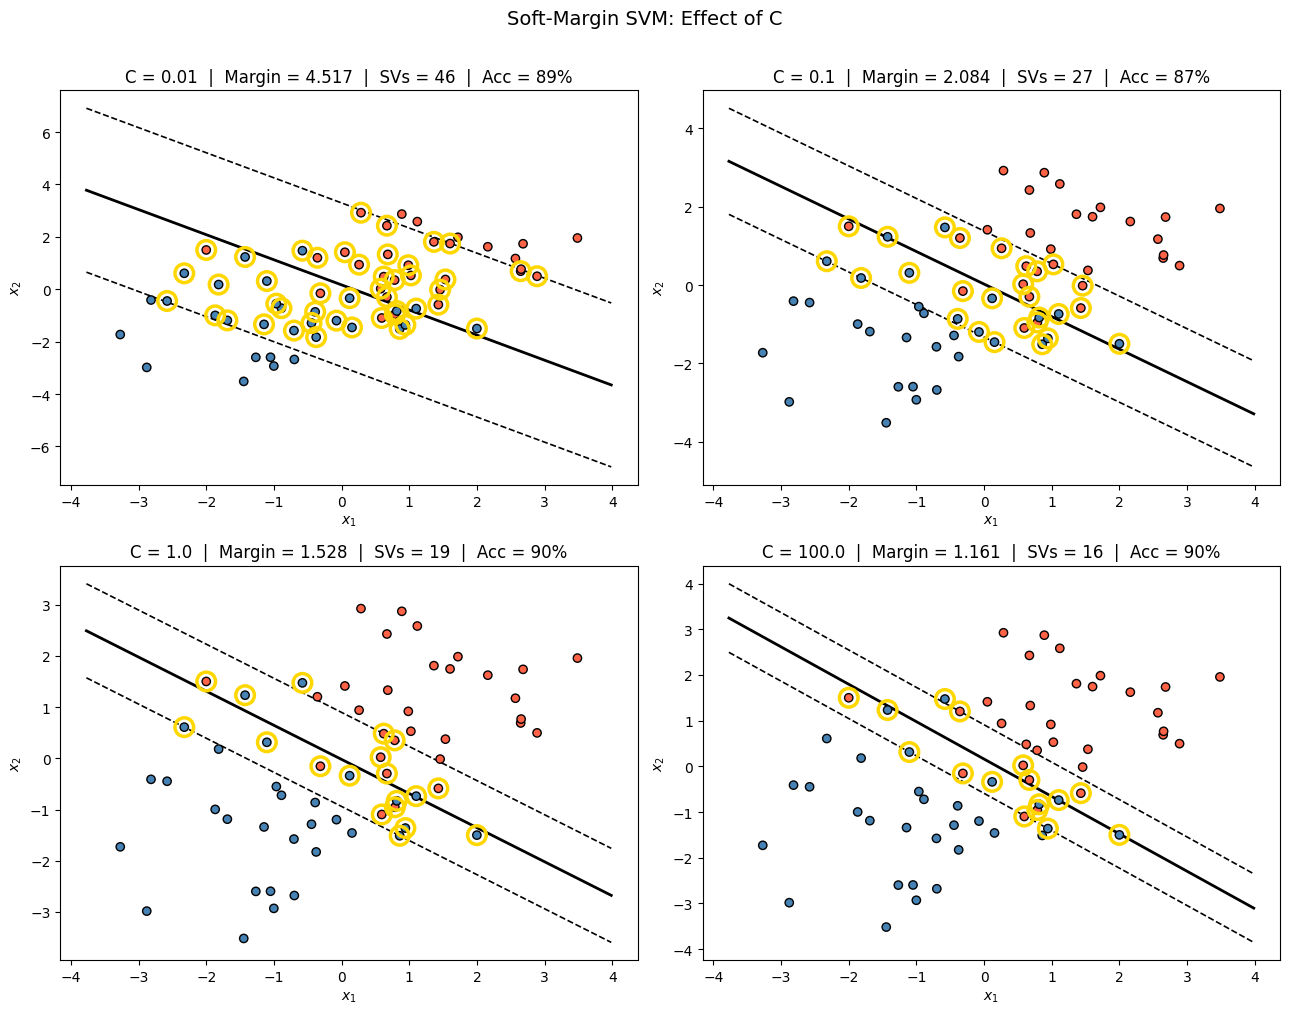

In [9]:
# Dataset with overlap + outliers
np.random.seed(7)
X_soft, y_soft = make_blobs(n_samples=60, centers=[[-1, -1], [1, 1]],
                             cluster_std=1.1, random_state=7)
y_soft = np.where(y_soft == 0, -1, 1)
X_soft = np.vstack([X_soft, [[-2.0, 1.5], [2.0, -1.5]]])
y_soft = np.append(y_soft, [1, -1])

C_values = [0.01, 0.1, 1.0, 100.0]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, C in zip(axes, C_values):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_soft, y_soft)
    w = clf.coef_[0]; b = clf.intercept_[0]
    sv = clf.support_vectors_
    colors = ['tomato' if yi == 1 else 'steelblue' for yi in y_soft]
    ax.scatter(X_soft[:, 0], X_soft[:, 1], c=colors, edgecolors='k', zorder=3)
    ax.scatter(sv[:, 0], sv[:, 1], s=180, facecolors='none',
               edgecolors='gold', linewidths=2.5, zorder=4)
    x1 = np.linspace(X_soft[:, 0].min() - 0.5, X_soft[:, 0].max() + 0.5, 300)
    if w[1] != 0:
        ax.plot(x1, -(w[0]*x1 + b)/w[1],       'k-',  linewidth=2)
        ax.plot(x1, -(w[0]*x1 + b - 1)/w[1],   'k--', linewidth=1.2)
        ax.plot(x1, -(w[0]*x1 + b + 1)/w[1],   'k--', linewidth=1.2)
    margin = 2 / np.linalg.norm(w)
    acc = np.mean(clf.predict(X_soft) == y_soft)
    ax.set_title(f'C = {C}  |  Margin = {margin:.3f}  |  SVs = {len(sv)}  |  Acc = {acc:.0%}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.suptitle('Soft-Margin SVM: Effect of C', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [10]:
print(f"{'C':>8} | {'Margin':>8} | {'# SVs':>6} | {'Train Acc':>10}")
print('-' * 42)
for C in C_values:
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_soft, y_soft)
    margin = 2 / np.linalg.norm(clf.coef_[0])
    n_sv   = len(clf.support_vectors_)
    acc    = np.mean(clf.predict(X_soft) == y_soft)
    print(f"{C:>8} | {margin:>8.4f} | {n_sv:>6} | {acc:>10.0%}")

print("\nObservation: as C increases, margin shrinks and training accuracy rises.")
print("Small C = wide margin = more robust; Large C = narrow margin = may overfit.")

       C |   Margin |  # SVs |  Train Acc
------------------------------------------
    0.01 |   4.5171 |     46 |        89%
     0.1 |   2.0835 |     27 |        87%
     1.0 |   1.5282 |     19 |        90%
   100.0 |   1.1612 |     16 |        90%

Observation: as C increases, margin shrinks and training accuracy rises.
Small C = wide margin = more robust; Large C = narrow margin = may overfit.


---
## Part 7: Concept Review Questions

Answer the following questions in the markdown cell below.

1. **What are support vectors?** Why do only these points matter for defining the SVM boundary?

2. **What happens when $C$ increases?** Does the margin get wider or narrower? Does training accuracy go up or down?

3. **Why does the Perceptron not guarantee maximum margin?** How is SVM different in its optimization objective?

4. **What is the difference between hard-margin and soft-margin SVM?** When would you use each?

5. **Why is Hinge loss preferred over 0-1 loss for training SVM?**

**Your answers:**

1. 

2. 

3. 

4. 

5. 

---
## Part 8: Extra Exercises

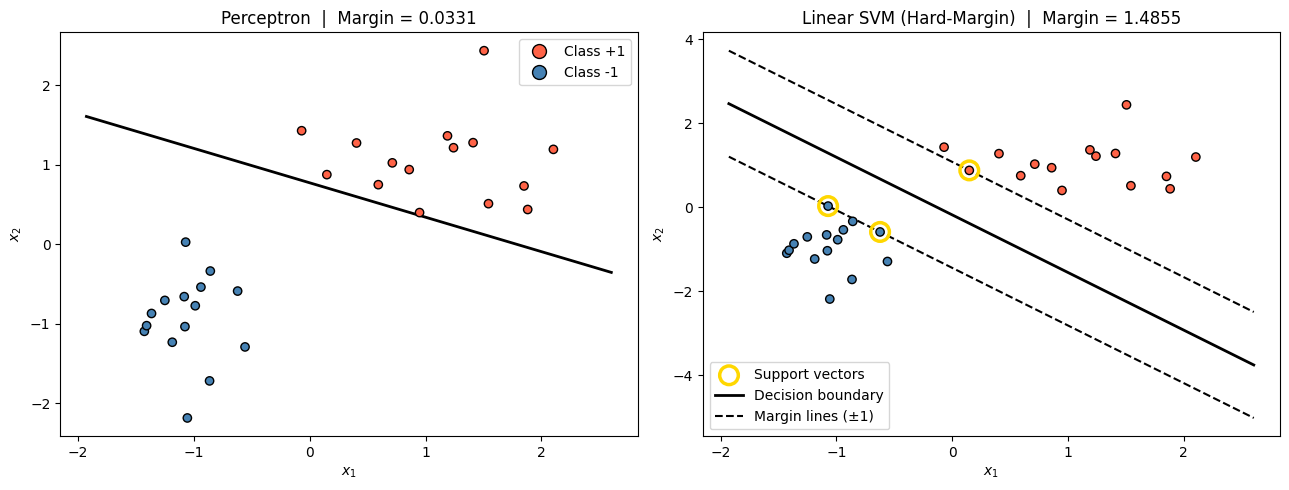

In [11]:
# Exercise A: Change random_seed to generate a new dataset.
# Does Perceptron always give a worse margin than SVM?

random_seed = 99   # <-- try different seeds

np.random.seed(random_seed)
X_exp, y_exp = make_blobs(n_samples=30, centers=[[-1, -1], [1, 1]],
                           cluster_std=0.5, random_state=random_seed)
y_exp = np.where(y_exp == 0, -1, 1)

p_exp = Perceptron(2)
p_exp.fit(X_exp, y_exp, n_epochs=50)

clf_exp = SVC(kernel='linear', C=1e6)
clf_exp.fit(X_exp, y_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.sca(axes[0])
plot_boundary(X_exp, y_exp, p_exp.w, p_exp.b,
              title=f'Perceptron  |  Margin = {compute_margin(X_exp, y_exp, p_exp.w, p_exp.b):.4f}')
plt.sca(axes[1])
plot_svm(X_exp, y_exp, clf_exp, title='Linear SVM (Hard-Margin)')
plt.tight_layout(); plt.show()

In [12]:
# Exercise B: Add more outliers to X_soft / y_soft and retrain with C = 1.
# How does the boundary change?

# Your experimental code:


---
## Optional: Beyond This Notebook

This notebook covers **linear SVM**, which matches the current lecture scope.

SVM can be extended to **nonlinear boundaries** using the **kernel trick** — replacing the dot product $x_i^T x_j$ with a kernel function $K(x_i, x_j)$:
- Polynomial kernel: $K(x_i, x_j) = (x_i^T x_j + c)^d$
- RBF kernel: $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$

This will be covered in a later lecture.